# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [2]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats

In [3]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [5]:
#from google.colab import drive
#drive.mount('/content/drive')

In [6]:

#cargamos los datos como arreglos numpy
features= np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("RRLyrae_labels_small.txt", delimiter=',')


In [7]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


In [8]:
df['RR_Lyrae'].value_counts(normalize=True)

RR_Lyrae
0    0.805477
1    0.194523
Name: proportion, dtype: float64

### Preguntas
1. ¿Este es un problema de clasificación o regresión?

    R: Este es un problema de clasificación, ya que el target es una etiqueta discreta y no un valor continuo

2. ¿Es un problema binario o multiclase?

    R: Es un problema binaria, de clases 0 y 1

3. ¿Qué representa la variable objetivo?

    R: Si es que la estrella es o no es una RR Lyrae en base a su color.

4. ¿Las clases están balanceadas o desbalanceadas?

    R: Están desbalanceadas, con ~19% estrellas RR Lyrae y el resto estrellas "comunes".

5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?

    R: Al ser ~81% de las estrellas clase 0, un modelo que prefuga "ninguna es RR Lyrae (clase 1) usa ese ~81 y no detectaría nada, por eso es mejor utilizar métricas que son "inmunes" al desbalanceo.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

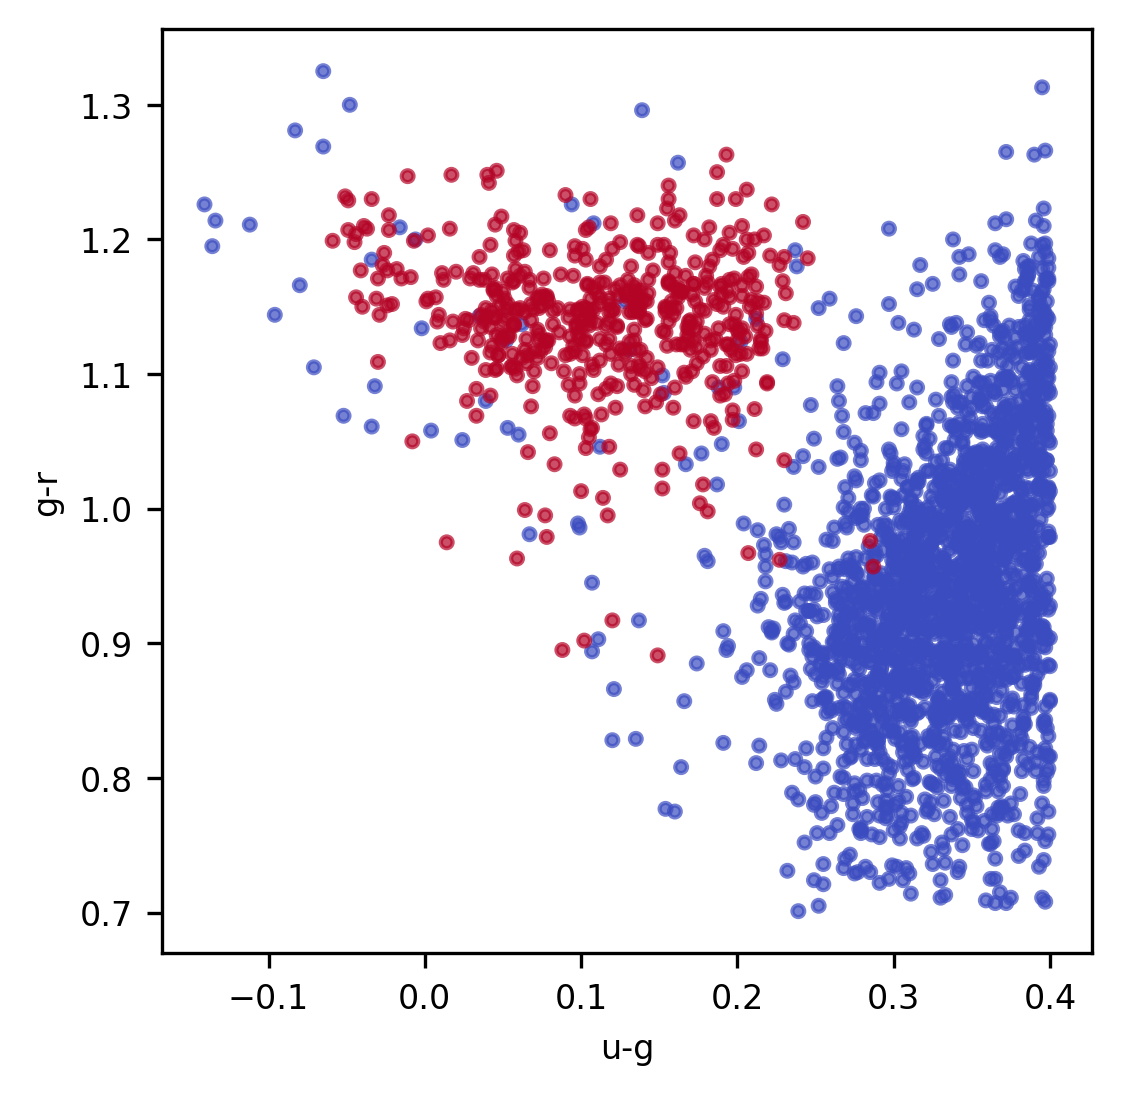

In [9]:
#complete la celda
plt.figure(figsize=(4,4))

sc=plt.scatter(df['u-g'], df['g-r'], c=df['RR_Lyrae'], cmap='coolwarm', s=8, alpha=0.7)
plt.xlabel('u-g')
plt.ylabel('g-r')
plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?

    R: Si, se puede ver una separación de grupos bastante clara. Casi todas las RR Lyrae están a la izquirda de 'u-g' = 0.25 habiendo un poco del grupo de azules ensuciando ese grupo rojo. Pero en su gran mayoría hay solo rojas (RR Lyrae)

2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?

    R: Si, ya que el arbol de decisión "cortaría" o mejor dicho haría umbrales perpendiculares a los ejes y viendo la separación de los grupos visualmente se puede notar una clara separación entre los grupos, que es justo lo que hace un arbol de decisión.

#### Separe los datos en entrenamiento y prueba

In [10]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [11]:
#complete la celda
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3, random_state=42, stratify=y)

In [12]:
X_train.shape

(1738, 4)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?

    R: Con una partición aleatoria, la proporción de RR Lyrae en train y test puede quedar distinta a la del conjunto completo por azar. Como la clase positiva es mucho menor, el test o el train podría quedar con muy pocos datos de esta misma.

2. ¿Por qué eso podría afectar la evaluación del modelo?

    R: Porque si el train queda con pocos de la clase positiva el modelo aprendería peor sobre esa clase.

3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

    R: Tener la misma proporcion de las clases entre train y test que en el conjunto original. 

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [13]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)
#entrene el modelo y genere las predicciones
y_pred=model_tree.predict(X_test)


In [14]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

RR_Lyrae
0    0.805524
1    0.194476
Name: proportion, dtype: float64
RR_Lyrae
0    0.805369
1    0.194631
Name: proportion, dtype: float64


#### Visualicemos el árbol

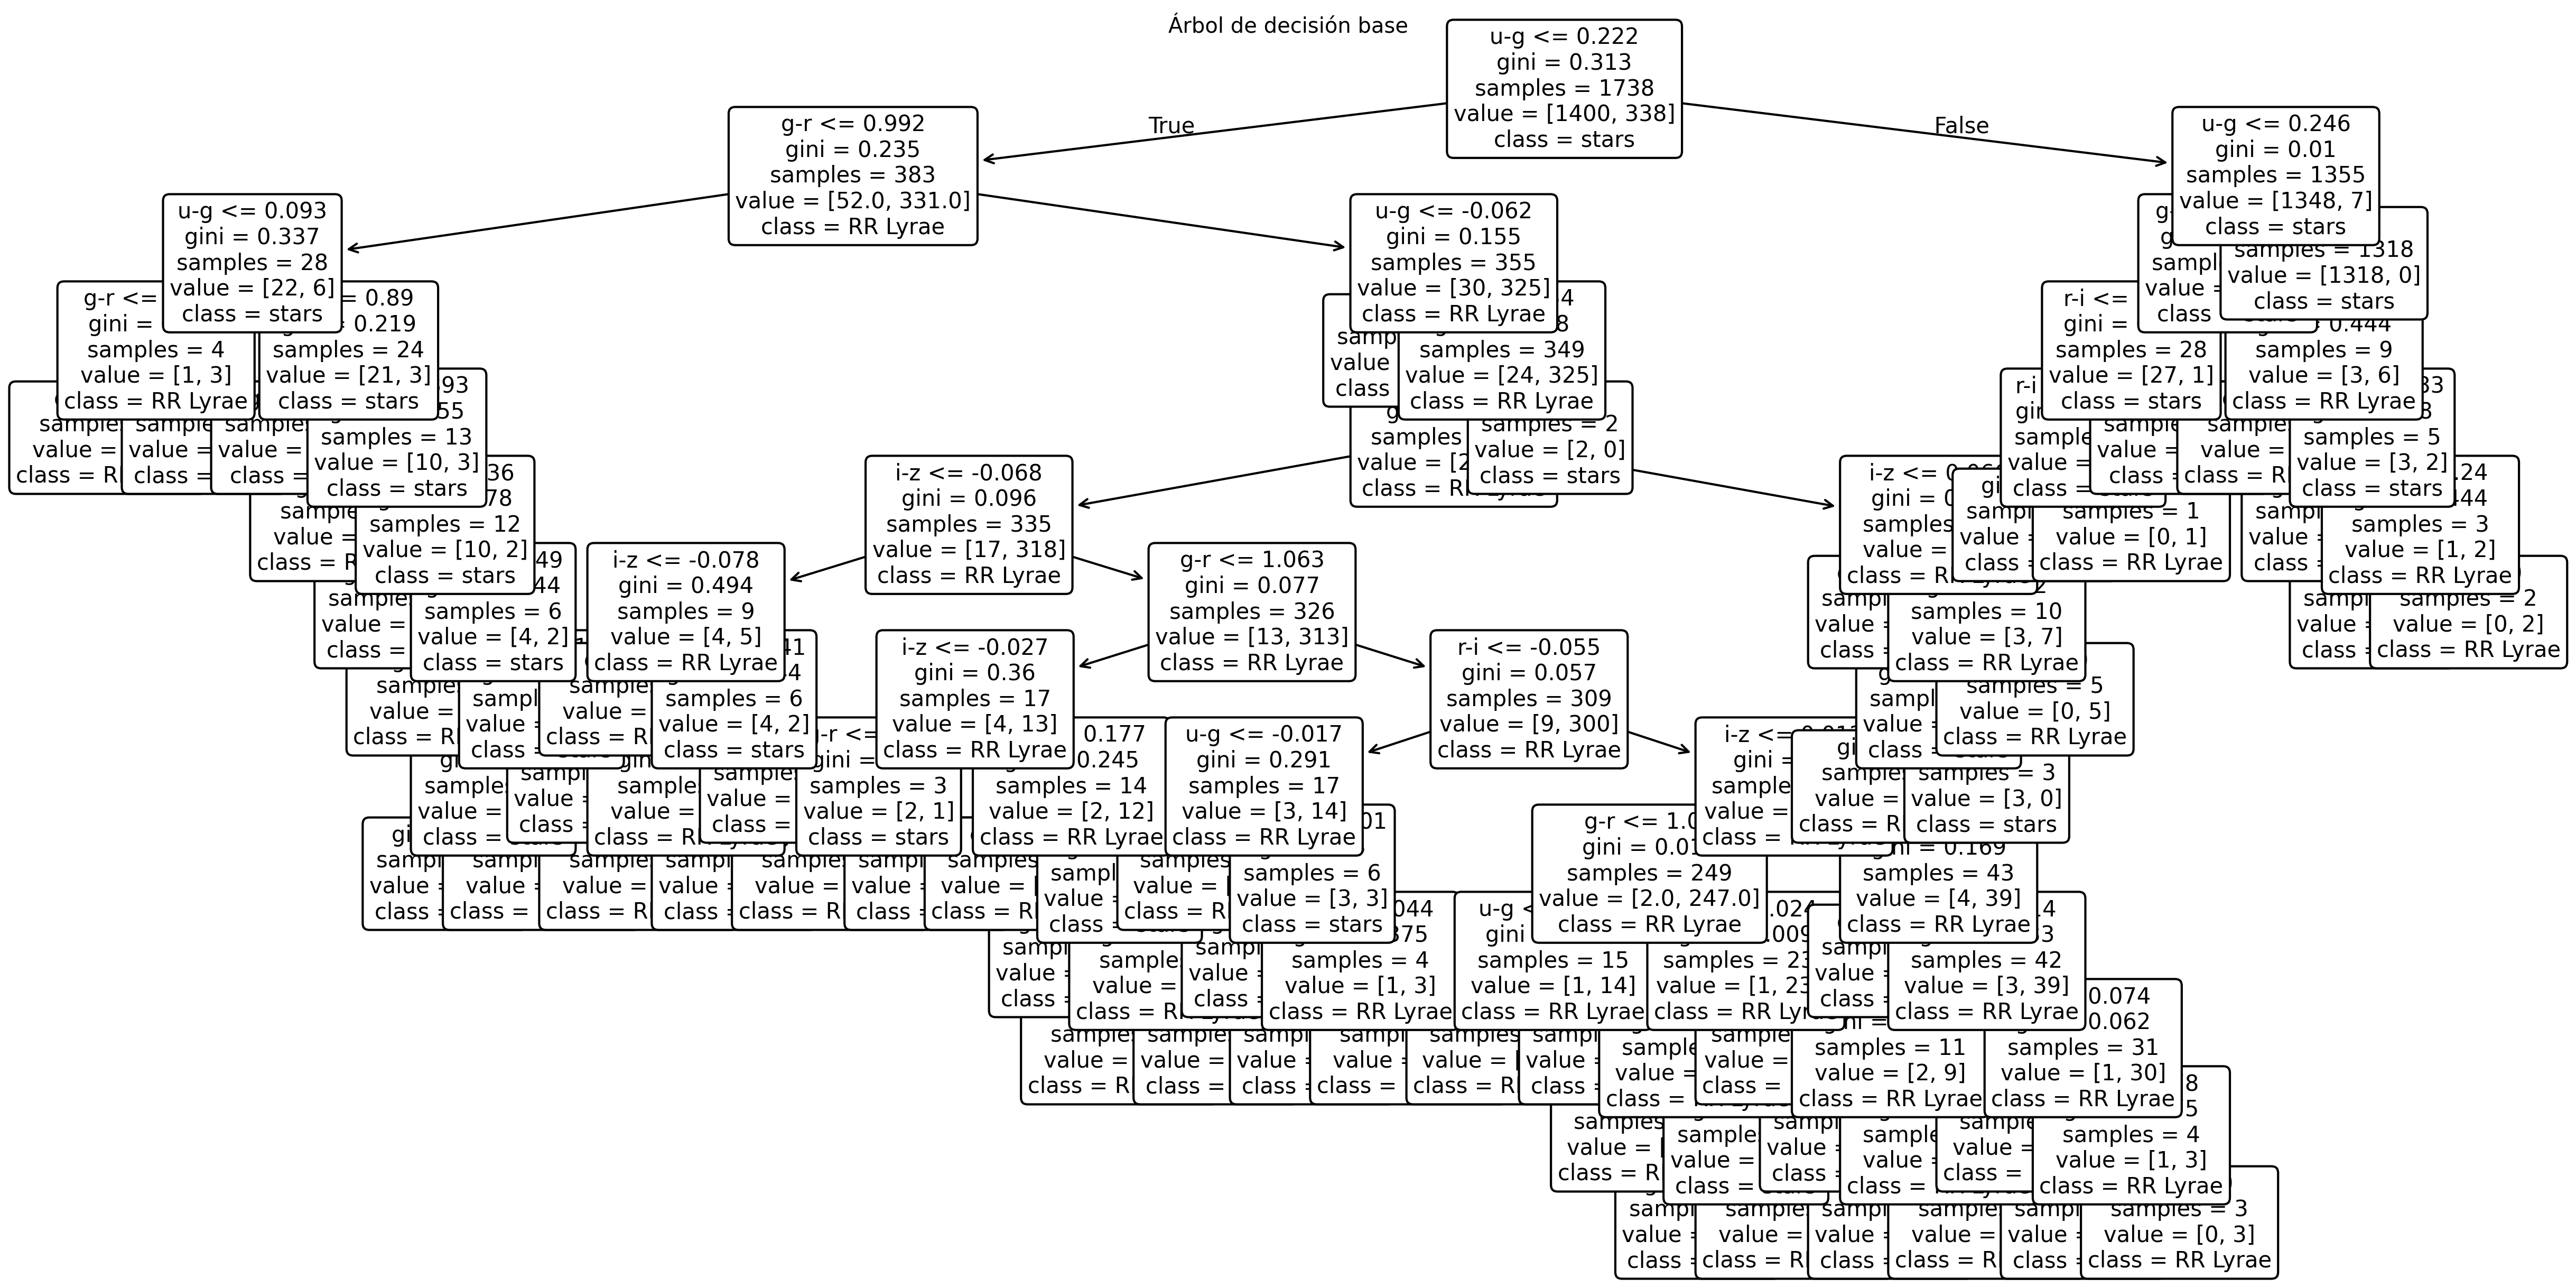

In [15]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

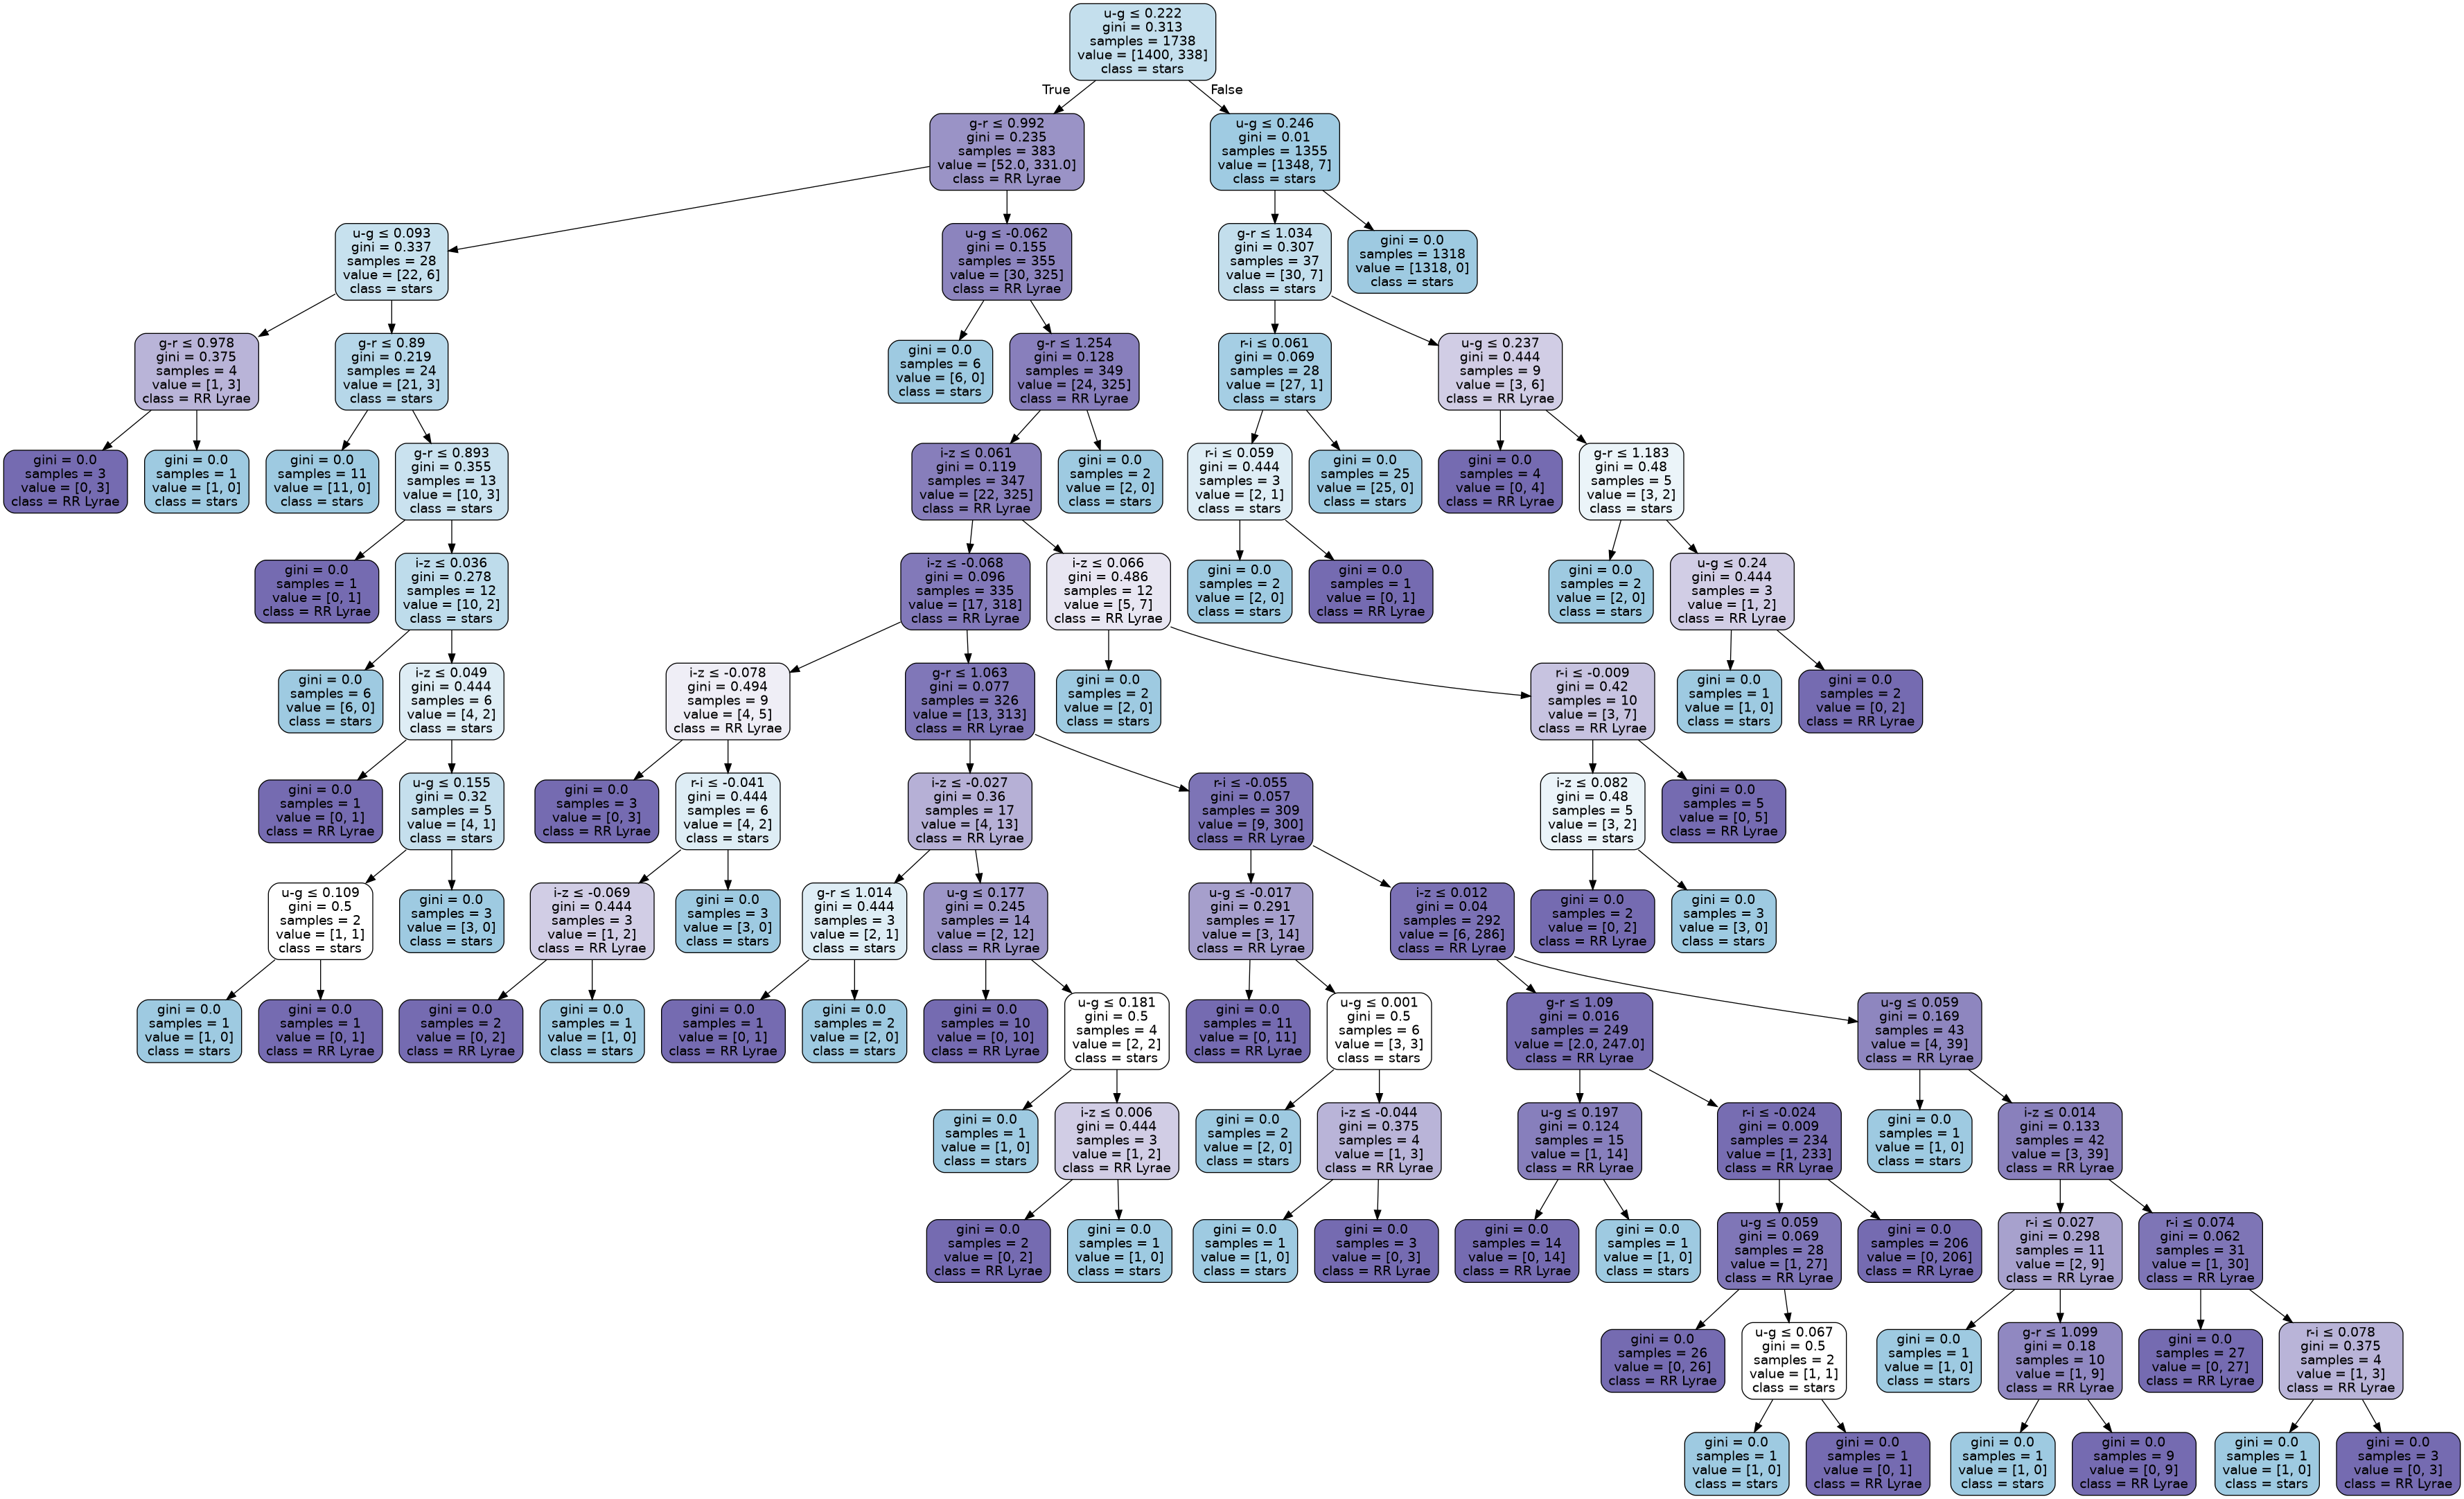

In [16]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.

    R: El arbol es bastante complejo, este tiene muchos niveles y muchos nodos que tienen muy pocas estrellas cada una, esto debe ser porque no está limitado.

2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

    R: Los nodos que tienen pocas estrellas por ejemeplo no serían tan confiables estadísticamente hablando y teniendo clases desbalanceadas la clase con muchos menores datos podría salir perjudicada. En resumen el modelo no generaliza muy bien.

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [17]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.978523489932886


#### Otras métricas

In [18]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.951048951048951
Recall   : 0.9379310344827586
F1-score : 0.9444444444444444


In [19]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[593,   7],
       [  9, 136]])

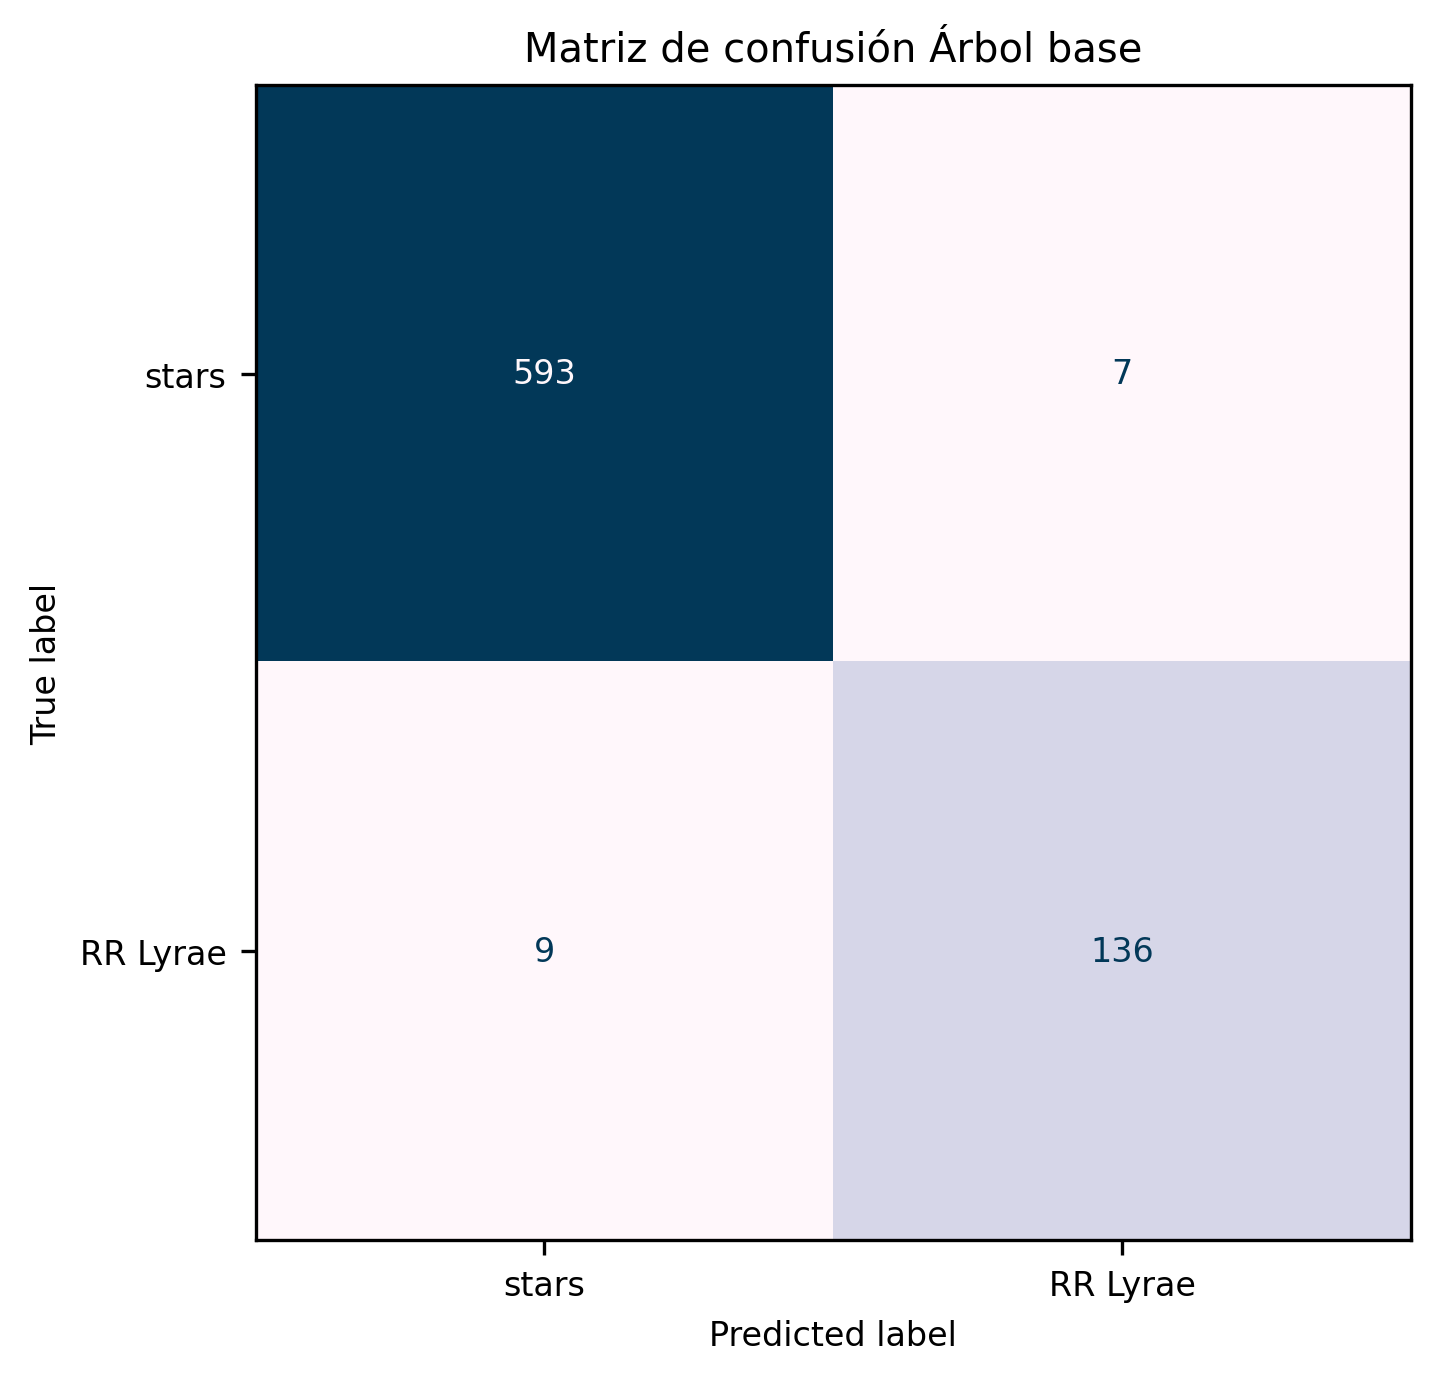

In [20]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   - verdaderos negativos (TN)
   - falsos positivos (FP)
   - falsos negativos (FN)
2. Calcule las métricas "a mano"



In [21]:
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2* (precision*recall)/ (precision+recall)

In [22]:
print("TN:", tn, " FP:", fp, " FN:", fn, " TP:", tp)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1       :", f1)

TN: 593  FP: 7  FN: 9  TP: 136
Accuracy : 0.978523489932886
Precision: 0.951048951048951
Recall   : 0.9379310344827586
F1       : 0.9444444444444445


### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo
      
      R: En este caso un falso positivo es una estrella que NO es RR Lyrae pero el clasificador la considera como una. Basicamente es como una estrella "impostora"
   
   - un falso negativo

      R: En este caso un falso negativo es lo contrario a lo anterior, una estrella que SI es RR Lyrae pero el clasificador la considera como que no lo es.

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

   R: El tipo de errores que preocuparían más serían los falsos negativos ya que cada uno de estos es una estrella RR Lyrae real que "perdemos". La metrica que querríamos máximizar en este caso sería Recall

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?

   R: Aqui los errores que preocuparían más serían los falsos positivos porque en este caso queremos aumentar la pureza (precision). Osea minimizar la contaminación de los casos positivos predichos.

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [23]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [24]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x70746968f340>

In [25]:
for train, test in cv1.split(X, y):
     print('train -  {}   |   test -  {}'.format(
         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [26]:
for train, test in cv2.split(X, y):
     print('train -  {}   |   test -  {}'.format(
         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [27]:
for train, test in cv3.split(X, y):
     print('train -  {}   |   test -  {}'.format(
         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [28]:
scores1 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv3, scoring = 'accuracy')

In [29]:
scores3

{'fit_time': array([0.01079297, 0.01029873, 0.01058531, 0.00848007, 0.00668001]),
 'score_time': array([0.00642157, 0.00247645, 0.00312209, 0.00291944, 0.00218821]),
 'test_score': array([0.98390342, 0.96981891, 0.96780684, 0.97379032, 0.95967742])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [30]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.784 0.379


In [31]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.968 0.012


In [32]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.971 0.008


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [33]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/home/nadorgen/astro/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nadorgen/astro/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nadorgen/astro/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nadorgen/astro/lib/python3.12/site-packages/sklea

In [34]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [35]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/home/nadorgen/astro/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nadorgen/astro/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nadorgen/astro/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nadorgen/astro/lib/python3.12/site-packages/sklea

In [36]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.912 1.000
0.932 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [37]:
model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [38]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [39]:
model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [40]:
np.sum(y_cv3-y_cv2)

np.int64(10)

In [41]:
np.sum(y_cv2)

np.int64(485)

In [42]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [43]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [44]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

In [45]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [46]:
model = DecisionTreeClassifier(random_state = 5)

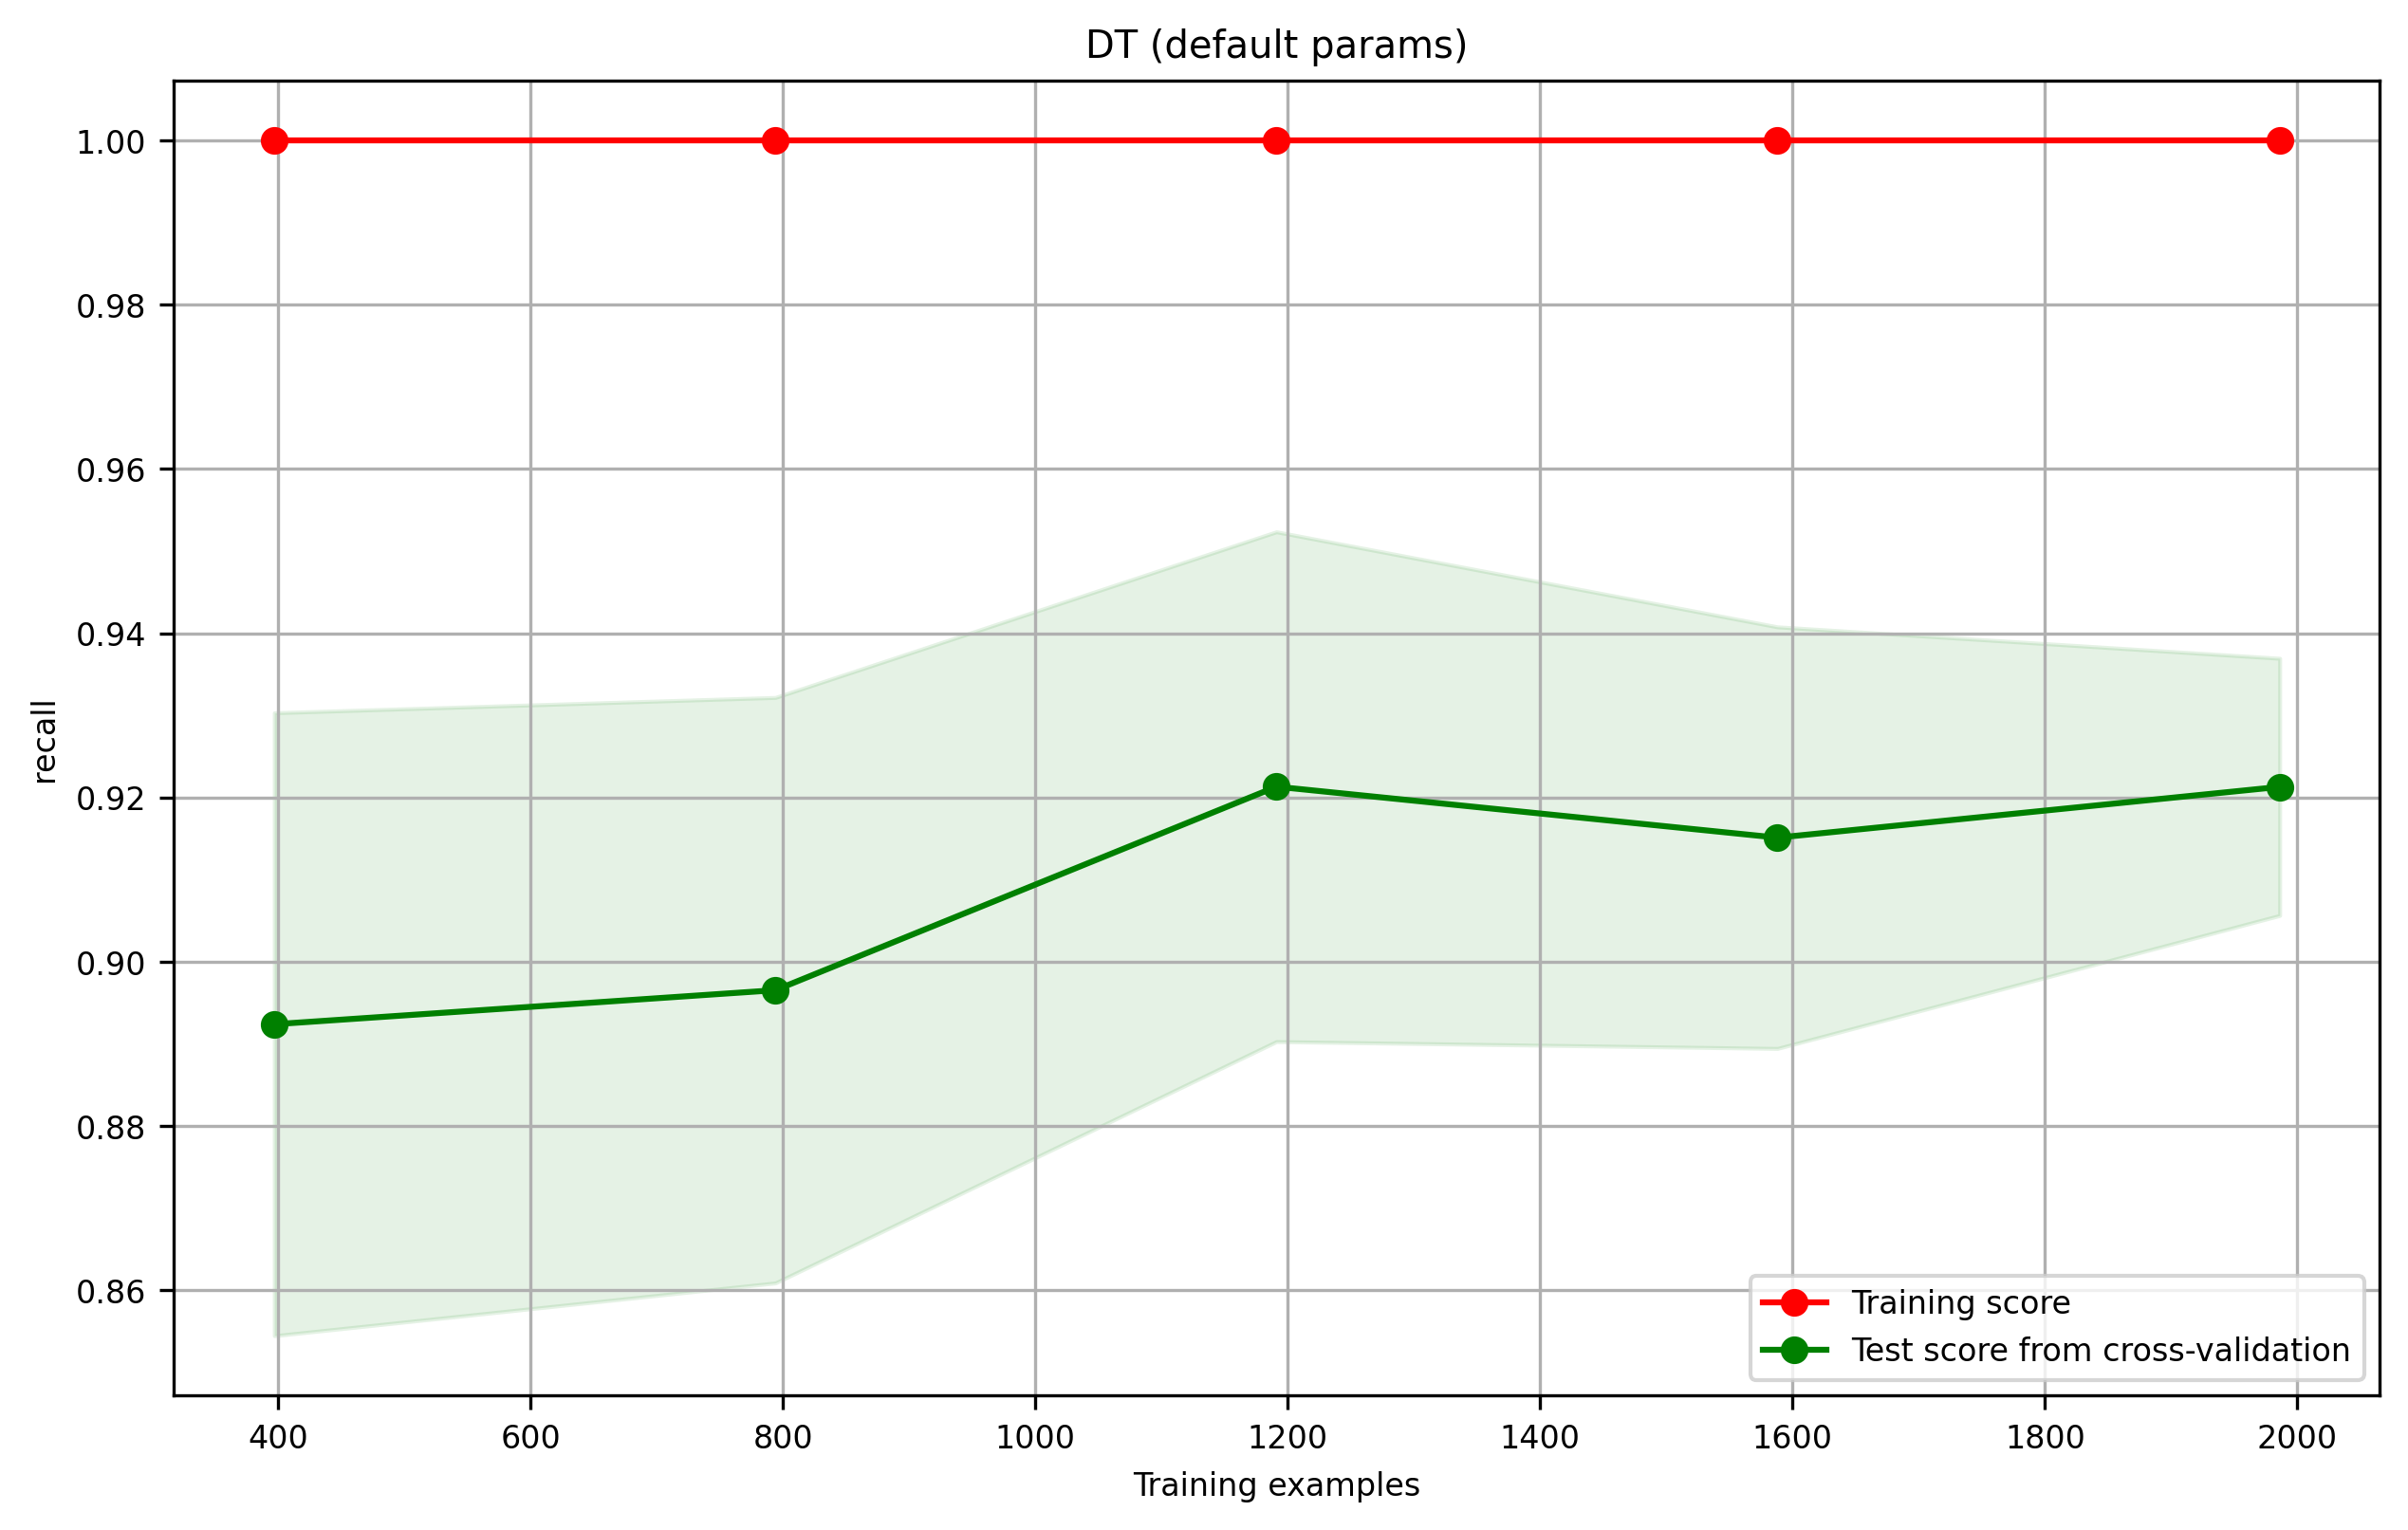

In [47]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

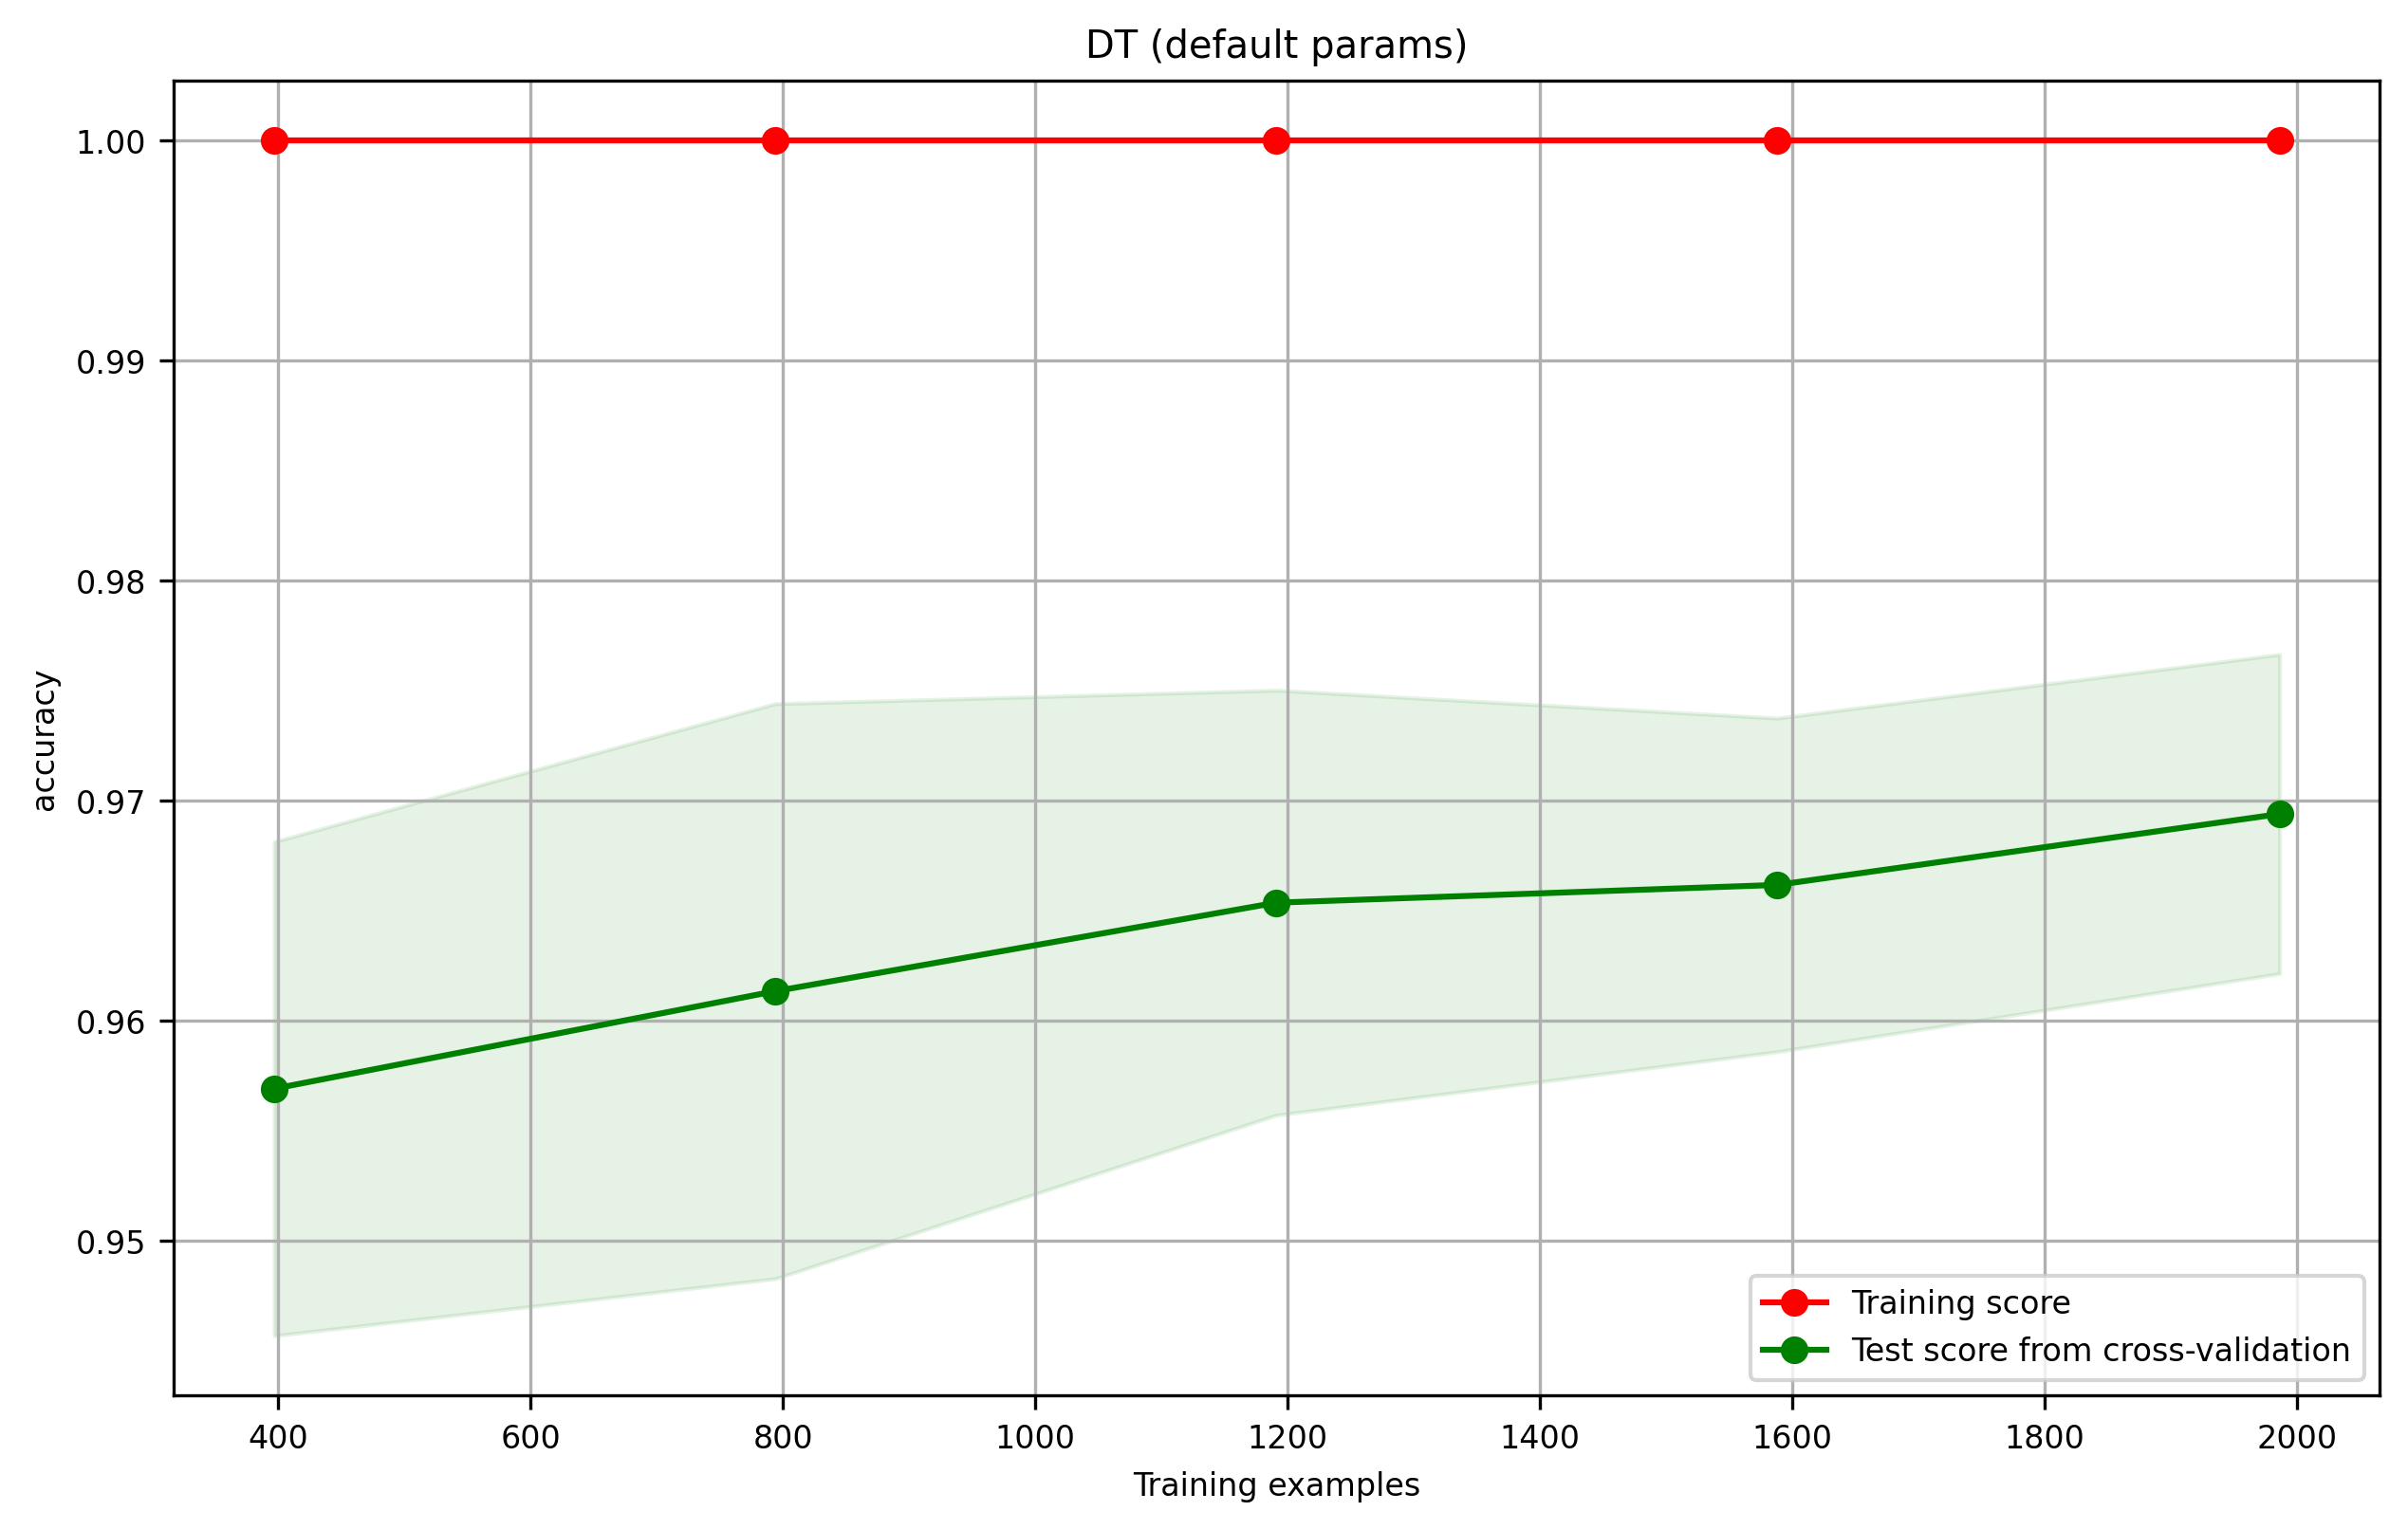

In [48]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?

    R: Si hay una brecha, y es bien importante. La curva de entrenamiento es plana en 1.00 para todos los tamaños, y en contraparte, la de validación está valores mas abajo tanto en accuracy como en recall. Que el modelo ajuste de manera perfecta el train independiente de la cantidad de ejemplos que reciba sugiere que está memorizando los datos y no aprendiendo un patrón de genelarización.

2. ¿El rendimiento de validación mejora al agregar más ejemplos?

    R: Si mejora, pero lentamente y de todas formas las curvas si se angostan al final, o sea que la estimación se hace más estable. Aunque la brecha no se acerque demasiado se nota una disminución de esta.

3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.

    R: Hablaría de alta varianza, ver una brecha que no se cierra al agregar datos indica varianza, y no sesgo, ya que si fuese sesgo ambas curvas deberían converger a un valor bajo.

4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.

    R: El arbol tiene un buen rendimiento, pero sobreajusta, ya que memoriza el conjunto de entrenamiento y no logra predecir bien cuando se agregan datos que no son del entrenamiento. La brecha es más grande en recall que en accuracy, lo que indica que el problema afecta a la detección de RR Lyrae. Como al agregar datos no ayuda, lo más razonable sería limitar al modelo para reducir su complejidad.

### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?

    R: Logró mejorar en todas las métricas como se puede más abajo. En accuracy. precision, recall, y f1 aumentó. La mejora más grande es en recall de 0.932 para el arbol base a 0.961.

2. ¿El árbol más simple empeoró o mejoró la generalización?

    R: La mejoró. La curva de trainingdel arbol simple muestra un train de ~0.97 en vez de 1, y la brecha con la curva de validación se hace cada vez más angosta al hacer uso de todos los datos. Además la curva de validación sigue subiendo hasta los 2000 examples sin estancarse en 1200 como antes que si lo hacía en el arbol base.

3. ¿Qué sugieren estos resultados sobre el árbol base?

    R: Que el arbol base estaba sobreajustando los datos y no agregaba información util sobre las fronteras entre clases por su complejidad.

4. En este problema, ¿parece conveniente usar el árbol sin restricciones?

    R: No ya que el arbol sin restricciones, como se ha dicho, es más complejo have overfitting sin apredenerse una generalización y es peor en todas las métricas de validación, por lo que no hay una razón para considerarlo "conveniente".

5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

    R: Esto depende del objetivo que se quiere buscar a la hora de trabajar con estos datos, por ejemplo si nuestra idea es no perder candidatas a RR Lyrae el recall es más relevante ya que no nos interesa perder estos datos reales. Pero por ejemplo si importara y esto y que además sea una muestra final pura, lo mejor es utilizar f1 que es un equilibrio entre presicion y recall.

In [49]:
metricas = ['accuracy', 'precision', 'recall', 'f1']

arbol_base   = DecisionTreeClassifier(random_state=42)
arbol_simple = DecisionTreeClassifier(max_depth=3, random_state=42)

for nombre, modelo in [('Árbol base', arbol_base), ('Árbol simple', arbol_simple)]:
    print(nombre)
    for m in metricas:
        s = cross_validate(modelo, X, y, cv=cv3, scoring=m)['test_score']
        print("  {:10s} {:.3f} +/- {:.3f}".format(m, s.mean(), s.std()))

Árbol base
  accuracy   0.971 +/- 0.004
  precision  0.920 +/- 0.012
  recall     0.932 +/- 0.014
  f1         0.926 +/- 0.011
Árbol simple
  accuracy   0.977 +/- 0.008
  precision  0.925 +/- 0.023
  recall     0.961 +/- 0.024
  f1         0.942 +/- 0.019


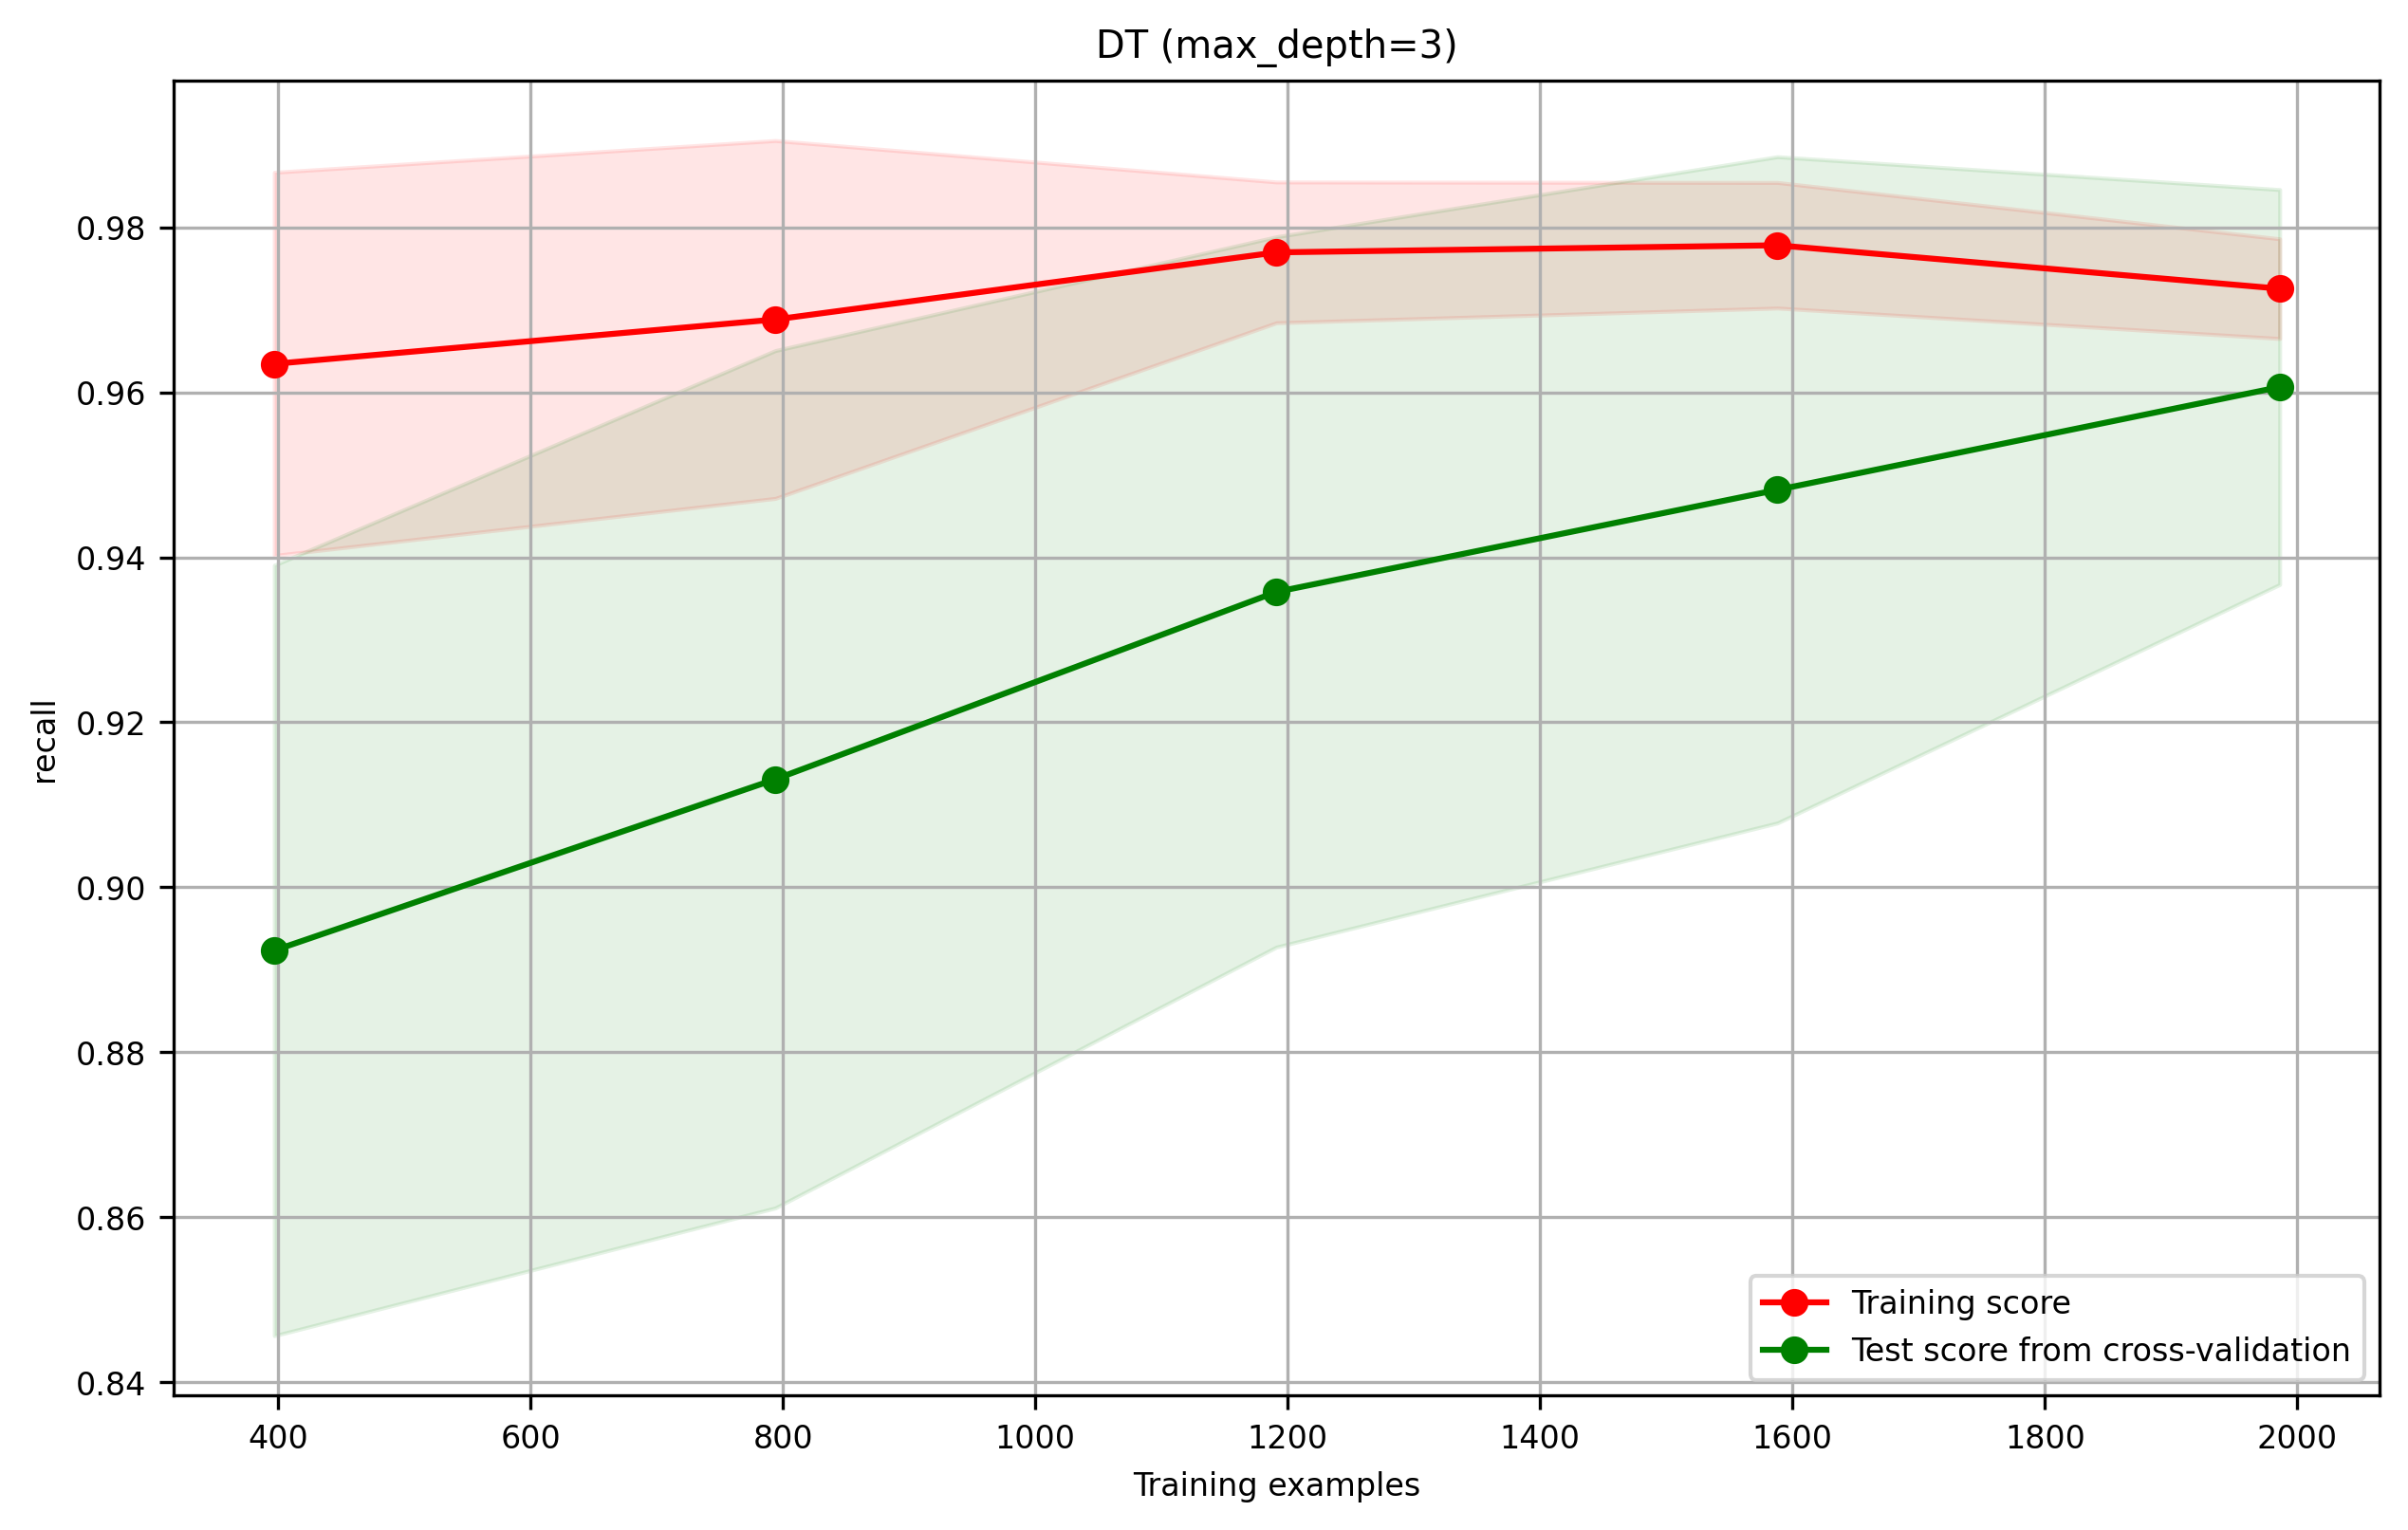

In [50]:
plot_learning_curve(arbol_simple, 'DT (max_depth=3)', X, y, cv=cv3, scoring='recall');

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?

   R: kNN co k=5 es muy parecido y supera de manera super leve al arbol simple. Como se puede ver en la comparación de más abajo. Las diferencias son bien pequeñas, asi que ambos modelos rinden bien. Lo interesante es que ambos son dos enfoques distintos y llegan a resultados de métricas parecidas, esto podría ser indicio de que poder separar las clases con dos formas distintas indicaría que la separación entre las clases es real.

2. ¿Qué ocurre cuando `k` es muy pequeño?

   R: cuando k esp pequeño el modelo sobreajusta, ya que con k=1 la predicción solo depende de un vecino, asi que cualquier estrella que esté mal ubicada o ruidosa afectaría los resultados.

3. ¿Qué ocurre cuando `k` es muy grande?

   R: Cuando k es muy grande el modelo se vuelve suave y la clase minoritaria es perjudicada. Como se puede ver más abajo entre k=20 y k=50 la precision car a 0.898 y 0.893 esto nos indica que hay menos pureza en la muestra al tener k altos, entran cada vez más estrellas comunes en la vecindad y aumentan los FP. el recall se mantiene alto pero a costa de una muestra más contaminada.

4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?

   R: El que da el mejor equilibrio es k=10, tiene el valor más alto de accuracy y tambien de f1, el cual denota el equilibrio entre precision y recall. Es el punto donde la curva deja de mejorar y empieza el deterioro de la pureza.

5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

   R:kNN a diferencia del arbol de decisión no impone una geometría particular a la frontere y se adapata a la forma que tengan los datos en el espacio. Si, por ejemplo, la separación entre RR Lyrae y el restoo fuera más inclinado y menos como lineas rectas en el plano, kNN capturaría mejor la forma que un arbol por esta ventaja.


In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

knn5 = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))

print("kNN (k=5)")
for m in metricas:
    s = cross_validate(knn5, X, y, cv=cv3, scoring=m)['test_score']
    print("  {:10s} {:.3f} +/- {:.3f}".format(m, s.mean(), s.std()))

kNN (k=5)
  accuracy   0.978 +/- 0.006
  precision  0.922 +/- 0.021
  recall     0.969 +/- 0.011
  f1         0.945 +/- 0.015


In [54]:
print("  k   accuracy  precision  recall    f1")
for k in [1, 3, 5, 10, 20, 50]:
    modelo = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    fila = [cross_validate(modelo, X, y, cv=cv3, scoring=m)['test_score'].mean() for m in metricas]
    print("{:4d}    {:.3f}     {:.3f}     {:.3f}   {:.3f}".format(k, *fila))

  k   accuracy  precision  recall    f1
   1    0.968     0.914     0.923   0.919
   3    0.977     0.923     0.961   0.941
   5    0.978     0.922     0.969   0.945
  10    0.979     0.919     0.977   0.947
  20    0.973     0.898     0.973   0.934
  50    0.972     0.893     0.973   0.931


In [55]:
#Comparación entre arbol y kNN

print("kNN (k=5)")
for m in metricas:
    s = cross_validate(knn5, X, y, cv=cv3, scoring=m)['test_score']
    print("  {:10s} {:.3f} +/- {:.3f}".format(m, s.mean(), s.std()))
print("Arbol simple")

for m in metricas:
        s = cross_validate(arbol_simple, X, y, cv=cv3, scoring=m)['test_score']
        print("  {:10s} {:.3f} +/- {:.3f}".format(m, s.mean(), s.std()))

kNN (k=5)
  accuracy   0.978 +/- 0.006
  precision  0.922 +/- 0.021
  recall     0.969 +/- 0.011
  f1         0.945 +/- 0.015
Arbol simple
  accuracy   0.977 +/- 0.008
  precision  0.925 +/- 0.023
  recall     0.961 +/- 0.024
  f1         0.942 +/- 0.019


## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.